In [1]:
import os
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

2025-08-09 19:15:31.502713: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-09 19:15:31.502743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-09 19:15:31.503538: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-09 19:15:31.509094: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-09 19:15:32.249289: W tensorflow/compiler/tf2

In [2]:
#generateors

train_ds = keras.utils.image_dataset_from_directory(
    directory ="CAT_DOG/train",
    labels="inferred",
    label_mode="int",
    batch_size=16,
    image_size=(256, 256),
    shuffle=True
)

Found 20000 files belonging to 2 classes.


2025-08-09 19:15:33.478573: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-09 19:15:33.529697: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-08-09 19:15:33.531875: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:

validation_ds = keras.utils.image_dataset_from_directory(
    directory ="CAT_DOG/test",
    labels="inferred",
    label_mode="int",
    batch_size=16,
    image_size=(256, 256),
    shuffle=True
)

Found 5000 files belonging to 2 classes.


In [4]:
len(os.listdir("CAT_DOG/train/dogs")), len(os.listdir("CAT_DOG/train/cats"))

(10000, 10000)

In [5]:
# Normalize the pixel values to be between 0 and 1
def process(image, label):
    image = tf.cast(image/255. , tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [6]:
# Creating the CNN Model

model = Sequential()

# 1st Conv Layer
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3))) # (3 X 3 X 3 + 1) X 32 = 896 trainable params
model.add(BatchNormalization()) # 4 X 32 = 128 trainable params; 2 X 32 = 64 non-trainable params
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 2nd Conv Layer
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu')) # (3 X 3 X 32 + 1) X 64 = 18496 trainable params
model.add(BatchNormalization()) # 4 X 64 = 256 trainable params; 2 X 64 = 128 non-trainable params
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# 3rd Conv Layer
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu')) # (3 X 3 X 64 + 1) X 128 = 73856 trainable params
model.add(BatchNormalization()) # 4 X 128 = 512 trainable params; 2 X 128 = 256 non-trainable params
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))

# Fully Connected Layers
model.add(Flatten()) # (30 X 30 X 128) = 115200
model.add(Dense(128, activation='relu')) # (115200 + 1) X 128 = 14745728 trainable params
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu')) # (128 + 1) X 64 = 8256 trainable params
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation='sigmoid')) # (64 + 1) X 1 = 65 trainable params

# No. of trainable params = 896 + 128 + 18496 + 256 + 73856 + 512 +  14745728 + 8256 + 65 = 14848193

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 254, 254, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 batch_normalization_1 (Bat  (None, 125, 125, 64)      256       
 chNormalization)                                                
                                                        

In [8]:
# from tensorflow.keras.utils import plot_model

# plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [9]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
history = model.fit(train_ds, epochs=50, validation_data=validation_ds)

Epoch 1/50


2025-08-09 19:15:36.208966: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-08-09 19:15:37.476384: I external/local_xla/xla/service/service.cc:168] XLA service 0x7e7dd4445cb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-09 19:15:37.476411: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2070, Compute Capability 7.5
2025-08-09 19:15:37.481563: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754747137.547044   21289 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 [==============================] - 49s 36ms/step - loss: 1.5431 - accuracy: 0.5687 - val_loss: 0.6412 - val_accuracy: 0.6548
Epoch 2/50
1250/1250 [==============================] - 45s 36ms/step - loss: 0.6501 - accuracy: 0.6398 - val_loss: 0.6245 - val_accuracy: 0.6342
Epoch 3/50
1250/1250 [==============================] - 45s 36ms/step - loss: 0.5980 - accuracy: 0.6838 - val_loss: 0.5989 - val_accuracy: 0.6364
Epoch 4/50
1250/1250 [==============================] - 45s 36ms/step - loss: 0.5431 - accuracy: 0.7289 - val_loss: 0.4905 - val_accuracy: 0.7618
Epoch 5/50
1250/1250 [==============================] - 45s 36ms/step - loss: 0.4779 - accuracy: 0.7780 - val_loss: 0.4567 - val_accuracy: 0.7894
Epoch 6/50
1250/1250 [==============================] - 45s 36ms/step - loss: 0.4221 - accuracy: 0.8157 - val_loss: 0.7111 - val_accuracy: 0.7310
Epoch 7/50
1250/1250 [==============================] - 45s 36ms/step - loss: 0.3520 - accuracy: 0.8506 - val_loss: 0.8379 - val_accura

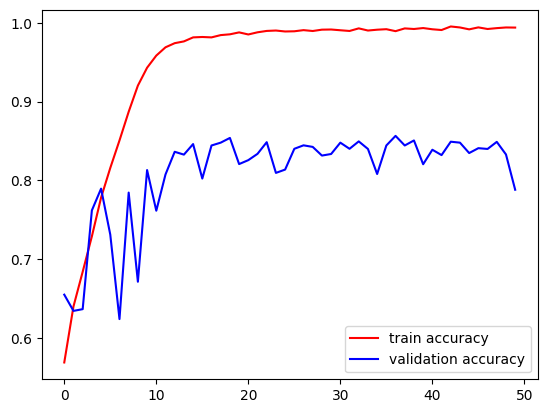

In [11]:
import matplotlib.pyplot as plt
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'],color ='red', label='train accuracy')
plt.plot(history.history['val_accuracy'], color='blue', label='validation accuracy')
plt.legend()
plt.show()

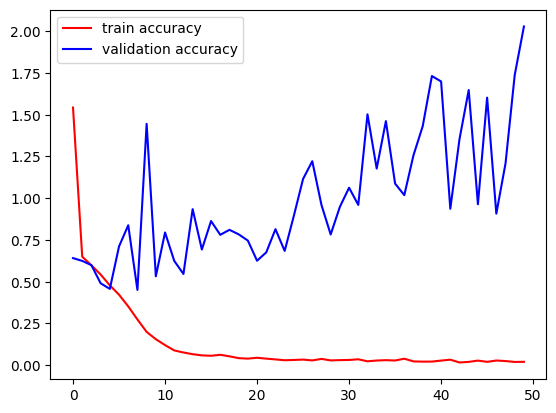

In [12]:
# Plot training & validation loss values
plt.plot(history.history['loss'],color ='red', label='train accuracy')
plt.plot(history.history['val_loss'], color='blue', label='validation accuracy')
plt.legend()
plt.show()

In [13]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("CAT_DOG/asd.jpg", target_size=(256, 256))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction:", prediction[0][0])
print("Class:", "Dog" if prediction[0][0] > 0.5 else "Cat")


1/1 [==============================] - 0s 263ms/step
Prediction: 1.8203869e-29
Class: Cat


In [14]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("CAT_DOG/asdf.jpg", target_size=(256, 256))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Prediction:", prediction[0][0])
print("Class:", "Dog" if prediction[0][0] > 0.5 else "Cat")

1/1 [==============================] - 0s 16ms/step
Prediction: 0.47804743
Class: Cat


In [15]:
model.save('cat_dog_model.h5')

/home/bhai/tf_gpu_1/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
